Grundlagen der Wechselstromlehre  {-}
===

# Wechselspannung und Wechselstrom

## Periodische Wechselspannung
Eine Wechselspannung ist eine zeitabhängige Spannung

$$
U(t)
$$

die sich periodisch wiederholt:

$$
U(t) = U(t + T)
$$

Die Frequenz ist

$$
\nu = \frac{1}{T}
$$

Zusammenhang zwischen Kreisfrequenz und Frequenz:

$$
\omega = 2\pi\nu
$$

## Sinusförmige Spannung und Strom
Im Praktikum werden sinusförmige Größen verwendet:

$$
U(t) = U_0 \sin(\omega t + \varphi_U)
$$

$$
I(t) = I_0 \sin(\omega t + \varphi_I)
$$

Phasenverschiebung:

$$
\Delta\varphi = \varphi_U - \varphi_I
$$

## Effektivwerte
Multimeter messen Effektivwerte:

$$
U_{\mathrm{eff}} = \frac{U_0}{\sqrt{2}}, \qquad I_{\mathrm{eff}} = \frac{I_0}{\sqrt{2}}
$$

## Leistung im Wechselstromkreis
Momentanleistung:

$$
P(t) = U(t)\, I(t)
$$

Zeitlicher Mittelwert:

$$
\langle P \rangle = U_{\mathrm{eff}} I_{\mathrm{eff}} \cos(\Delta\varphi)
$$

---

#  Wechselstromwiderstände (Impedanzen)

##  Ohm'scher Widerstand
$$
Z_R = R
$$
Keine Phasenverschiebung.

## Kondensator
Reeller Wechselstromwiderstand:

$$
X_C = \frac{1}{\omega C}
$$

Komplexe Impedanz:

$$
Z_C = -i X_C = -\frac{i}{\omega C}
$$

Der Strom eilt der Spannung um $90^\circ$ voraus.

## Spule
Reeller Wechselstromwiderstand:

$$
X_L = \omega L
$$

Komplexe Impedanz:

$$
Z_L = i X_L = i\omega L
$$

Der Strom hinkt um $90^\circ$ hinterher.

---

# Komplexe Schreibweise

Spannung:

$$
\hat U = U_0 e^{i(\omega t + \varphi_U)}
$$

Strom:

$$
\hat I = I_0 e^{i(\omega t + \varphi_I)}
$$

Komplexe Impedanz:

$$
Z = \frac{\hat U}{\hat I}
= \frac{U_0}{I_0} e^{i\Delta\varphi}
$$

Vorteil:  
Das Ohm'sche Gesetz gilt in komplexer Form:

$$
\hat U = Z\, \hat I
$$

---

# Serienschaltung von Impedanzen

Beispiel: Serienschaltung von $R$ und $X_C$:

$$
Z_{\mathrm{ges}} = R - iX_C
$$

Betrag:

$$
|Z_{\mathrm{ges}}| = \sqrt{R^2 + X_C^2}
$$

Spannungen:

$$
U_R = I R, \qquad U_C = I X_C
$$

Gesamtspannung:

$$
U_{\mathrm{ges}} = \sqrt{ U_R^2 + U_C^2 }
$$

Phasenverschiebung:

$$
\tan\Delta\varphi = \frac{X}{R}
$$

---

# Bestimmung einer unbekannten Impedanz

In einer Serienschaltung:

$$
I = \frac{U_R}{R} = \frac{U_X}{|X|}
$$

Daraus:

$$
|X| = R\frac{U_X}{U_R}
$$

---

# Serienschwingkreis (RLC-Kreis)

Gesamtimpedanz:

$$
Z = R + i\left(\omega L - \frac{1}{\omega C}\right)
$$

Betrag:

$$
|Z| = \sqrt{ R^2 + \left(\omega L - \frac{1}{\omega C}\right)^2 }
$$

## Resonanzfrequenz

Resonanzbedingung:

$$
\omega L = \frac{1}{\omega C}
$$

Resonanzkreisfrequenz:

$$
\omega_0 = \frac{1}{\sqrt{LC}}
$$

Bei Resonanz:

$$
|Z(\omega_0)| = R
$$

## Resonanzkurve der Kondensatorspannung

$$
U_C(\omega) =
U_0 \,
\frac{\omega_0^2}{\sqrt{(\omega_0^2 - \omega^2)^2 + 4\delta^2\omega^2}}
$$

Dämpfung:

$$
\delta = \frac{R}{2L}
$$

Maximum:

$$
\omega_{\max} = \sqrt{\omega_0^2 - 2\delta^2}
$$

---



===== RC-Analyse =====
C         = 1.014e-06 F ± 2.774e-09 F
R²        = 0.99969

===== RL-Analyse =====
L         = 1.514e-02 H ± 2.053e-04 H
R²        = 0.98985


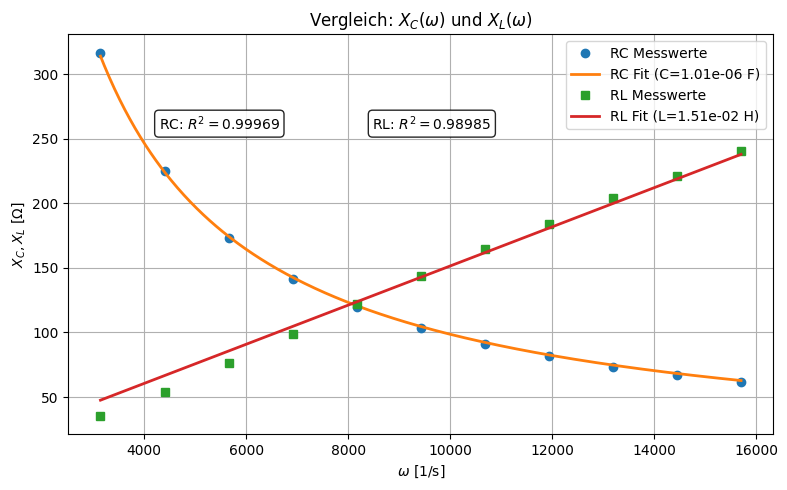


===== RLC-Analyse =====
omega0    = 8.286e+03 1/s ± 3.613e+01
delta     = 1.697e+03 1/s ± 4.710e+01
A         = 1.045e+00 ± 1.862e-02
R²        = 0.99606


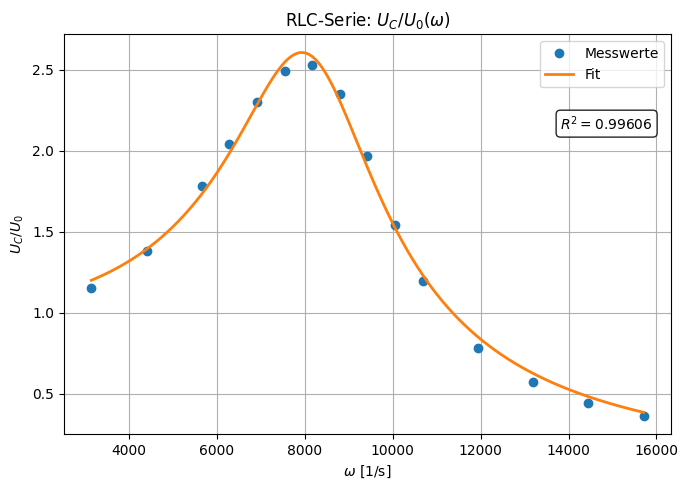

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

###############################################################################
# Messdaten
###############################################################################

# Ohmscher Widerstand
R_OHM = 26.2   # gemessener Widerstand [Ohm]

# RC-Messungen
nu_rc = np.array([500, 700, 900, 1100, 1300, 1500, 1700, 1900, 2100, 2300, 2500])
UR_rc = np.array([0.081, 0.111, 0.139, 0.163, 0.184, 0.202, 0.217, 0.231, 0.242, 0.25, 0.258])
UC_rc = np.array([0.979, 0.952, 0.919, 0.881, 0.84, 0.799, 0.757, 0.718, 0.679, 0.641, 0.606])

# RL-Messungen
nu_rl = np.array([500, 700, 900, 1100, 1300, 1500, 1700, 1900, 2100, 2300, 2500])
UR_rl = np.array([0.361, 0.32, 0.279, 0.243, 0.213, 0.19, 0.171, 0.156, 0.143, 0.133, 0.123])
UL_rl = np.array([0.484, 0.661, 0.809, 0.918, 0.992, 1.041, 1.073, 1.096, 1.112, 1.122, 1.129])

#[0.346, 0.345, 0.344, 0.343, 0.342, 0.34, 0.339, 0.337, 0.335, 0.333, 0.33]
#[0.01, 0.015, 0.02, 0.024, 0.028, 0.033, 0.038, 0.042, 0.046, 0.05, 0.054]

# RLC-Messungen
nu_rlc = np.array([500, 700, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1900, 2100, 2300, 2500])
U0_rlc = np.array([0.983, 0.913, 0.775, 0.688, 0.606, 0.543, 0.506, 0.502, 0.532, 0.59, 0.654, 0.75, 0.805, 0.836, 0.854])
UC_rlc = np.array([1.134, 1.261, 1.38, 1.404, 1.394, 1.354, 1.28, 1.178, 1.048, 0.911, 0.782, 0.588, 0.461, 0.373, 0.309])


###############################################################################
# Theorie-Funktionen
###############################################################################

def omega(nu):
    return 2 * np.pi * nu

def Xc_theory(w, C):
    return 1.0 / (w * C)

def Xl_theory(w, L):
    return w * L

def resonance_ratio(w, w0, delta, A):
    num = w0**2
    den = np.sqrt((w0**2 - w**2)**2 + 4 * delta**2 * w**2)
    return A * num / den


###############################################################################
# R²
###############################################################################

def r_squared(y, yfit):
    ss_res = np.sum((y - yfit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - ss_res/ss_tot


def add_r2_box(ax, R2, label=None, x=0.97, y=0.85):
    if label is None:
        txt = rf"$R^2 = {R2:.5f}$"
    else:
        txt = rf"{label}: $R^2 = {R2:.5f}$"
    ax.text(x, y, txt,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))


###############################################################################
# RC & RL ohne Unsicherheiten, ohne chi²
###############################################################################

def evaluate_rc_rl_omega():

    # ---------- RC ----------
    w_rc = omega(nu_rc)
    Xc_meas = R_OHM * (UC_rc / UR_rc)

    popt_c, pcov_c = curve_fit(Xc_theory, w_rc, Xc_meas, p0=[1e-6])
    C_fit = popt_c[0]
    C_err = np.sqrt(np.diag(pcov_c))[0]

    Xc_fit = Xc_theory(w_rc, C_fit)
    R2_c   = r_squared(Xc_meas, Xc_fit)

    print("\n===== RC-Analyse =====")
    print(f"C         = {C_fit:.3e} F ± {C_err:.3e} F")
    print(f"R²        = {R2_c:.5f}")

    # ---------- RL ----------
    w_rl = omega(nu_rl)
    Xl_meas = R_OHM * (UL_rl / UR_rl)

    popt_l, pcov_l = curve_fit(Xl_theory, w_rl, Xl_meas, p0=[1e-3])
    L_fit = popt_l[0]
    L_err = np.sqrt(np.diag(pcov_l))[0]

    Xl_fit = Xl_theory(w_rl, L_fit)
    R2_l   = r_squared(Xl_meas, Xl_fit)

    print("\n===== RL-Analyse =====")
    print(f"L         = {L_fit:.3e} H ± {L_err:.3e} H")
    print(f"R²        = {R2_l:.5f}")

    # ---------- gemeinsamer Plot ----------
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(r"Vergleich: $X_C(\omega)$ und $X_L(\omega)$")

    ax.plot(w_rc, Xc_meas, "o", label="RC Messwerte")
    ax.plot(np.linspace(min(w_rc), max(w_rc), 500),
            Xc_theory(np.linspace(min(w_rc), max(w_rc), 500), C_fit),
            linewidth=2, label=rf"RC Fit (C={C_fit:.2e} F)")

    ax.plot(w_rl, Xl_meas, "s", label="RL Messwerte")
    ax.plot(np.linspace(min(w_rl), max(w_rl), 500),
            Xl_theory(np.linspace(min(w_rl), max(w_rl), 500), L_fit),
            linewidth=2, label=rf"RL Fit (L={L_fit:.2e} H)")

    ax.set_xlabel(r"$\omega$ [1/s]")
    ax.set_ylabel(r"$X_C, X_L$ [$\Omega$]")
    ax.grid()
    ax.legend()

    add_r2_box(ax, R2_c, label="RC", x=0.30, y=0.80)
    add_r2_box(ax, R2_l, label="RL", x=0.60, y=0.80)

    plt.tight_layout()
    plt.show()


###############################################################################
# RLC ohne Unsicherheiten, ohne chi²
###############################################################################

def evaluate_rlc_omega():
    w = omega(nu_rlc)
    ratio = UC_rlc / U0_rlc

    idx = np.argmax(ratio)
    w0_start = w[idx]
    delta_start = w0_start / 10

    popt, pcov = curve_fit(
        resonance_ratio, w, ratio,
        p0=[w0_start, delta_start, 1.0]
    )
    w0_fit, delta_fit, A_fit = popt
    w0_err, delta_err, A_err = np.sqrt(np.diag(pcov))

    ratio_fit = resonance_ratio(w, w0_fit, delta_fit, A_fit)
    R2   = r_squared(ratio, ratio_fit)

    print("\n===== RLC-Analyse =====")
    print(f"omega0    = {w0_fit:.3e} 1/s ± {w0_err:.3e}")
    print(f"delta     = {delta_fit:.3e} 1/s ± {delta_err:.3e}")
    print(f"A         = {A_fit:.3e} ± {A_err:.3e}")
    print(f"R²        = {R2:.5f}")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_title(r"RLC-Serie: $U_C/U_0(\omega)$")

    ax.plot(w, ratio, "o", label="Messwerte")
    w_fit = np.linspace(min(w), max(w), 1000)
    ax.plot(w_fit, resonance_ratio(w_fit, w0_fit, delta_fit, A_fit),
            label="Fit", linewidth=2)

    ax.set_xlabel(r"$\omega$ [1/s]")
    ax.set_ylabel(r"$U_C/U_0$")
    ax.grid()
    ax.legend()

    add_r2_box(ax, R2, x=0.97, y=0.80)

    plt.tight_layout()
    plt.show()


###############################################################################
# Main
###############################################################################

if __name__ == "__main__":
    evaluate_rc_rl_omega()
    evaluate_rlc_omega()
